In [ ]:
import retinanalysis as ra
import merge
import matplotlib.pyplot as plt

<module 'merge' from '/Users/riekelabbackup/Desktop/Vyom/RetinAnalysis/nbs/merge.py'>

In [ ]:
exp_name = '20250306C'
chunk_name = 'chunk4'

rb = ra.AnalysisChunk(exp_name, chunk_name)

Loading VCD from /Volumes/Vyom MEA/analysis/20250306C/chunk4/kilosort2.5 ...
VCD loaded with 534 cells.

Loaded spatial maps for channels [0, 2] and 534 cells of shape (126, 202, 2)
Spatial maps have been padded to align with RF parameters.



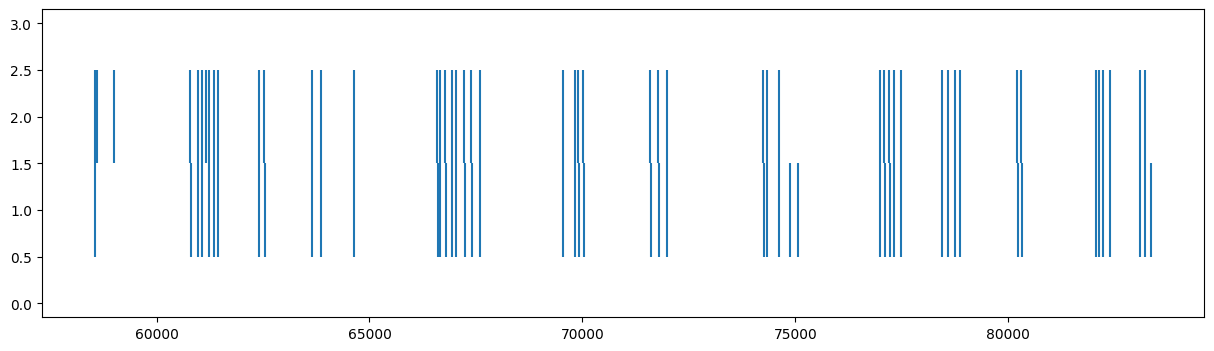

In [11]:
vcd = rb.vcd
plt.figure(figsize=(15,4))
plt.eventplot(vcd.get_spike_times_for_cell(201)[:50], lineoffsets=1)
plt.eventplot(vcd.get_spike_times_for_cell(288)[:50], lineoffsets=2)

In [54]:
import importlib
importlib.reload(merge)
dup_ids = [201, 288]
d_sts = {cid: vcd.get_spike_times_for_cell(cid) for cid in dup_ids}
df_st = merge.merge_spike_trains(d_sts, 'dirty')
merge.summarize_merger_df(df_st)

Merging spikes without any shift correction ('dirty' method)
Using minimum ISI of 30 samples (1.5 ms)
Cell 201: Removing 57 of 81752 spikes violating refractory period
Cell 201: 81695 spikes remain after removal
Cell 288: Removing 1 of 101615 spikes violating refractory period
Cell 288: 101614 spikes remain after removal


,original_unit,n_unique,n_shared,n_total
0,201,1173,80522,81695
1,288,21078,80536,101614


In [25]:
df_st[df_st['original_unit']==288]['shared'].value_counts()

shared
True     80537
False    21078
Name: count, dtype: int64

In [55]:
import importlib
importlib.reload(merge)
d_test = {0: [32], 1: [17, 50]}
df_test = merge.merge_spike_trains(d_test, 'dirty')
merge.summarize_merger_df(df_test)

Merging spikes without any shift correction ('dirty' method)
Using minimum ISI of 30 samples (1.5 ms)


,original_unit,n_unique,n_shared,n_total
0,0,0,1,1
1,1,0,2,2


In [53]:
df_test

,original_unit,original_spike_time,adjusted_spike_time,valid,shared,spike_id
0,1,17,17,True,True,0
1,0,32,32,False,True,0
2,1,50,50,False,True,0


In [35]:
merge.summarize_merger_df(df_st)

,original_unit,n_unique,n_shared,n_total
0,201,1221,80522,81695
1,288,101341,80536,101614


In [19]:
d_sts[201]

array([   58552,    60801,    60978, ..., 74103336, 74415143, 74431521],
      dtype=int32)

In [ ]:
df_st = merge.merge_spike_trains_cp(d_sts, 'dirty')

In [17]:
df_st['unique'].value_counts()

unique
True     102561
False     80806
Name: count, dtype: int64